In [37]:
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

In [27]:
os.makedirs("out/plots", exist_ok=True)

In [28]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text)

    text = re.sub(r'<.*?>', ' ', text) #remove html tags
    text = re.sub(r'http\S+', ' ', text) #remove urls
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) #remove puctutation marks and numbers
    text = text.lower() #convert text into lowercase

    tokens = [w for w in text.split() if w not in stop_words and len(w) > 2] #remove stop words and words with length less than 3
    tokens = [lemmatizer.lemmatize(w) for w in tokens] #lemmatize the words

    return ' '.join(tokens)

In [29]:
#Helper function to load training data
def load_training_data(path):
    texts, labels = [], []

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 4:
                label = int(parts[0]) #label
                title = parts[1] #title
                body = parts[3] #body

                texts.append(title + " " + body)
                labels.append(label)

    return texts, labels

In [30]:
#Helper function to load test data
def load_test_data(path):
    texts = []

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                title = parts[0] #title
                body = parts[2] #body

                texts.append(title + " " + body)

    return texts

In [31]:
#Cleaning data
X_raw, y = load_training_data("data/trainset.txt")
X_test_raw = load_test_data("data/testsetwithoutlabels.txt")

X_clean = [clean_text(x) for x in X_raw]
X_test_clean = [clean_text(x) for x in X_test_raw]

In [32]:
#Splitting data into training and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
#Tf idf vectorization
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test_clean)

In [ ]:
#Grid search for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_vec, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'C': 10, 'solver': 'liblinear'}
Best CV Score: 0.98125


In [36]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_table = cv_results[['param_C','param_solver','mean_test_score','rank_test_score']]
cv_table.to_csv("out/cv/results.csv", index=False)

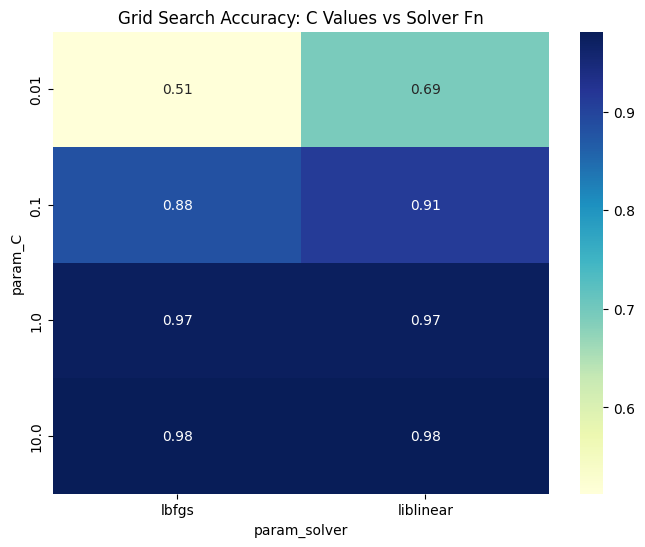

<Figure size 640x480 with 0 Axes>

In [43]:
# Reshape data for a heatmap
pivot_table = cv_table.pivot(index='param_C', columns='param_solver', values='mean_test_score')

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu')
plt.title('Grid Search Accuracy: C Values vs Solver Fn')
plt.show()
plt.savefig("out/plots/grid_search_heatmap.png")